In [3]:
# ===============================================================
# 🩺 Lung Cancer Detection using ResNet50 (Final Optimized Version)
# ===============================================================

# ===============================================================
# 1. Imports
# ===============================================================
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras import backend as K

In [4]:
# ===============================================================
# 2. Dataset Loading
# ===============================================================
DATA_DIR = r"C:\Users\dell\OneDrive\Documents\lung-cancer-project\data\raw\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset"
IMG_SIZE = 128
SEED = 42

class_names = ["Malignant cases", "Bengin cases", "Normal cases"]

X_list, y_list = [], []

for label_idx, cls in enumerate(class_names):
    folder = os.path.join(DATA_DIR, cls)
    files = glob(os.path.join(folder, "*"))
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_list.append(img)
        y_list.append(label_idx)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("✅ Dataset loaded:", X.shape, y.shape)
print("📊 Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

✅ Dataset loaded: (1097, 128, 128) (1097,)
📊 Class distribution: {0: 561, 1: 120, 2: 416}


In [5]:
# ===============================================================
# 3. Train/Test Split (BEFORE Oversampling)
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("📚 Original Train Split:", dict(zip(*np.unique(y_train, return_counts=True))))
print("🧪 Test Split:", dict(zip(*np.unique(y_test, return_counts=True))))

📚 Original Train Split: {0: 448, 1: 96, 2: 333}
🧪 Test Split: {0: 113, 1: 24, 2: 83}


In [8]:
# ===============================================================
# 4. Oversample Benign Class (ONLY in Training)
# ===============================================================
X_train_benign = X_train[y_train == 1]
y_train_benign = y_train[y_train == 1]

X_extra, y_extra = resample(
    X_train_benign, y_train_benign,
    replace=True,
    n_samples=len(X_train_benign)*3,
    random_state=SEED
)

X_train = np.concatenate([X_train, X_extra])
y_train = np.concatenate([y_train, y_extra])

print("✅ After Oversampling:", dict(zip(*np.unique(y_train, return_counts=True))))

✅ After Oversampling: {0: 448, 1: 384, 2: 333}


In [9]:
# ===============================================================
# 5. Preprocess Input for ResNet50
# ===============================================================
# ResNet expects 3 channels and preprocess_input scaling
X_train = preprocess_input(np.repeat(X_train[..., np.newaxis], 3, axis=-1))
X_test = preprocess_input(np.repeat(X_test[..., np.newaxis], 3, axis=-1))

In [10]:
# ===============================================================
# 6. Data Augmentation
# ===============================================================
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)
datagen.fit(X_train)

In [11]:
# ===============================================================
# 7. Build ResNet50 Model (Pretrained)
# ===============================================================
base = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False  # freeze base initially

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
resnet_model = models.Model(inputs, outputs)

In [12]:
# ===============================================================
# 8. Define Focal Loss
# ===============================================================
def sparse_categorical_focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        focal_loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=1))
    return loss

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=sparse_categorical_focal_loss(gamma=2., alpha=0.25),
    metrics=["accuracy"]
)

resnet_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 4, 4, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │           6,147 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
# ===============================================================
# 9. Callbacks and Class Weights
# ===============================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]
class_weight = {0: 2.0, 1: 1.0, 2: 2.0}  # give higher weight to minority classes

In [14]:
# ===============================================================
# 10. Training Phase 1 (Frozen Base)
# ===============================================================
history = resnet_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks
)

C:\Users\dell\anaconda3\envs\drowsyml\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 949ms/step - accuracy: 0.2905 - loss: 0.8125 - val_accuracy: 0.5227 - val_loss: 0.1488 - learning_rate: 1.0000e-04
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 868ms/step - accuracy: 0.4221 - loss: 0.5210 - val_accuracy: 0.7136 - val_loss: 0.0850 - learning_rate: 1.0000e-04
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 35s 938ms/step - accuracy: 0.4525 - loss: 0.4714 - val_accuracy: 0.7545 - val_loss: 0.0669 - learning_rate: 1.0000e-04
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 35s 933ms/step - accuracy: 0.4717 - loss: 0.4121 - val_accuracy: 0.7955 - val_loss: 0.0588 - learning_rate: 1.0000e-04
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 810ms/step - accuracy: 0.5499 - loss: 0.3012 - val_accuracy: 0.8045 - val_loss: 0.0521 - learning_rate: 1.0000e-04
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 870ms/step - accuracy: 0.5742 - loss: 0.3125 - val_accuracy: 0.7909 - val_loss: 0.0532 - learning_rate: 1.0000e-04
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 36s 978ms/step - acc

In [15]:
# ===============================================================
# 🔧 Fine-Tuning Phase (ResNet50)
# ===============================================================
for layer in base.layers[-30:]:
    layer.trainable = True

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=sparse_categorical_focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)

fine_tune_history = resnet_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks
)

# Evaluate again
fine_test_loss, fine_test_acc = resnet_model.evaluate(X_test, y_test)
print(f"\n🏆 Fine-Tuned Test Accuracy: {fine_test_acc*100:.2f}%")


Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6388 - loss: 0.1884 - val_accuracy: 0.8182 - val_loss: 0.0390 - learning_rate: 1.0000e-05
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7099 - loss: 0.1180 - val_accuracy: 0.8455 - val_loss: 0.0334 - learning_rate: 1.0000e-05
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7281 - loss: 0.1068 - val_accuracy: 0.8909 - val_loss: 0.0259 - learning_rate: 1.0000e-05
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7857 - loss: 0.0785 - val_accuracy: 0.9045 - val_loss: 0.0215 - learning_rate: 1.0000e-05
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7969 - loss: 0.0731 - val_accuracy: 0.9045 - val_loss: 0.0193 - learning_rate: 1.0000e-05
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8168 - loss: 0.0604 - val_accuracy: 0.9000 - val_loss: 0.0175 - learning_rate: 1.0000e-05
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8147 - loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 613ms/step - accuracy: 0.9402 - loss: 0.0122

🏆 Final Test Accuracy: 94.09%
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 

📄 Classification Report:

                 precision    recall  f1-score   support

Malignant cases       1.00      0.97      0.99       113
   Bengin cases       0.84      0.67      0.74        24
   Normal cases       0.89      0.98      0.93        83

       accuracy                           0.94       220
      macro avg       0.91      0.87      0.89       220
   weighted avg       0.94      0.94      0.94       220



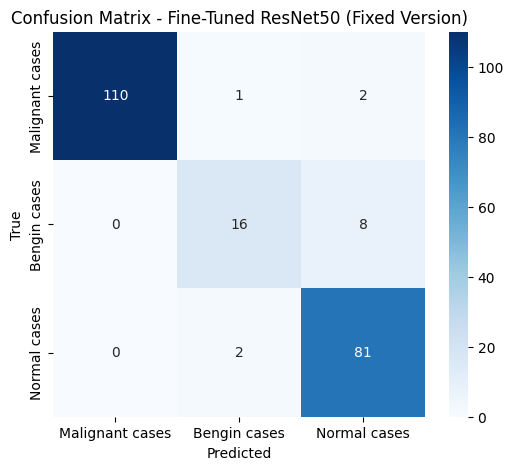

In [16]:
# ===============================================================
# 12. Evaluation
# ===============================================================
test_loss, test_acc = resnet_model.evaluate(X_test, y_test)
print(f"\n🏆 Final Test Accuracy: {test_acc*100:.2f}%")

y_pred_proba = resnet_model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-Tuned ResNet50 (Fixed Version)")
plt.show()


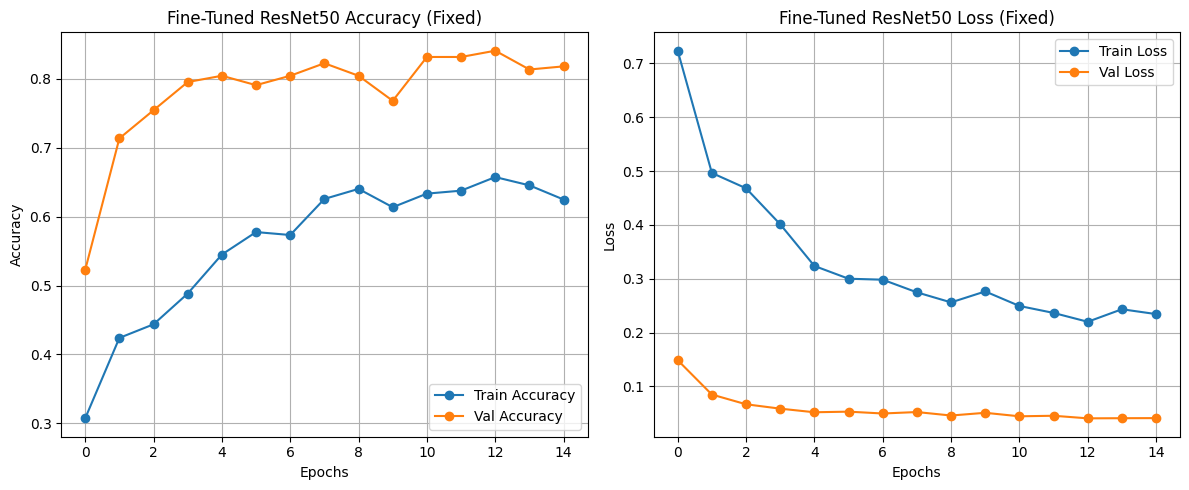

In [17]:
# ===============================================================
# 13. Training Curves
# ===============================================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Fine-Tuned ResNet50 Accuracy (Fixed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Fine-Tuned ResNet50 Loss (Fixed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
# ===============================================================
# 14. Summary Output
# ===============================================================
print("\n📊 Final Model Performance Summary")
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"🧮 Test Loss: {test_loss:.4f}")
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
print(f"🏆 Best Epoch: {best_epoch}")
print(f"⭐ Best Validation Accuracy: {best_val_acc*100:.2f}%")


📊 Final Model Performance Summary
✅ Test Accuracy: 94.09%
🧮 Test Loss: 0.0118
🏆 Best Epoch: 13
⭐ Best Validation Accuracy: 84.09%
